# Display some predictions

In [1]:
from pathlib import Path
from config import MODEL_NAME, PREDICT_RUNS_DIR
import os

PREDICTIONS_FOLDER = PREDICT_RUNS_DIR / f"sahi_{MODEL_NAME}"

#check if folder exists and not empty:
if PREDICTIONS_FOLDER.exists() and any(PREDICTIONS_FOLDER.iterdir()):
    print(f"Folder '{PREDICTIONS_FOLDER}' exists and has {len(list(PREDICTIONS_FOLDER.iterdir()))} predictions.")

Folder 'c:\Users\jonas\source\repos\school\cvi\pipeline\runs\detect\predict\sahi_ir_animal_detection' exists and has 1359 predictions.


## random samplespace
save random samplespace form all 1k predictions - to make this reproduceable

In [2]:
#save 50 random samples from Predictions to a new folder for visualization:
import random
import shutil
SAMPLE_SIZE = 50
SAMPLE_FOLDER = PREDICT_RUNS_DIR / f"SAMPLESPACE_{MODEL_NAME}"
if not SAMPLE_FOLDER.exists():
    SAMPLE_FOLDER.mkdir(parents=True)
    prediction_files = [path.name for path in PREDICTIONS_FOLDER.iterdir() if path.is_file()]
    samples = random.sample(prediction_files, min(SAMPLE_SIZE, len(prediction_files)))
    for sample in samples:
        shutil.copy(PREDICTIONS_FOLDER / sample, SAMPLE_FOLDER / sample)
    print(f"Copied {len(samples)} samples to '{SAMPLE_FOLDER}'.")

Copied 50 samples to 'c:\Users\jonas\source\repos\school\cvi\pipeline\runs\detect\predict\SAMPLESPACE_ir_animal_detection'.


OUTPUT - Random Predictions:
Randomly selected prediction: 264_26036.jpg
Randomly selected prediction: 283_9799.jpg
Randomly selected prediction: 162_8581.jpg
Randomly selected prediction: 162_8581.jpg
Randomly selected prediction: 261_28549.jpg
Randomly selected prediction: 162_6299.jpg


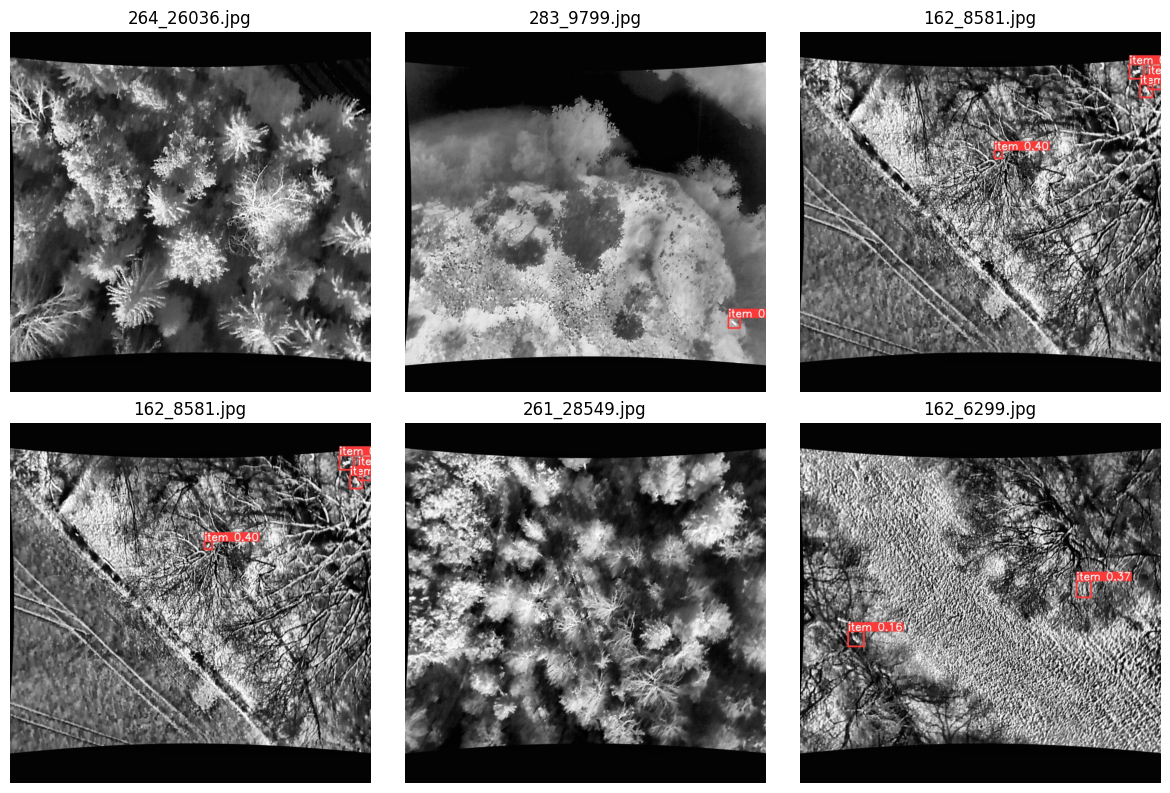

In [3]:
import os
import random
from PIL import Image
import matplotlib.pyplot as plt

print("OUTPUT - Random Predictions:")

fig, axes = plt.subplots(2, 3, figsize=(12, 8))

for ax in axes.flatten():
    random_prediction = random.choice([path.name for path in SAMPLE_FOLDER.iterdir() if path.is_file()])
    print(f"Randomly selected prediction: {random_prediction}")

    img = Image.open(SAMPLE_FOLDER / random_prediction)
    ax.imshow(img)
    ax.set_title(random_prediction)
    ax.axis("off")

plt.tight_layout()
plt.show()